# LightGBM 디지털 소외계층 분류 모델

## 개요

한국 디지털정보격차 실태조사 데이터를 기반으로 K-means pseudo-label(`digital_stage`)을 예측하는  
**LightGBM 분류 모델**을 학습·평가함.

MLP·SVM과 동일한 feature(`MODEL_FEATURES` 118개) 및 평가 지표를 사용해 공정하게 비교함.

| 단계 | 이름 | 특징 |
|------|------|------|
| 1단계 | 완전 소외 | 모든 디지털 역량 점수 음수 |
| 2단계 | 부분 적응 | 역량 점수 소폭 양수 |
| 3단계 | 자립 적응 | 역량 점수 전반적으로 높음 |


## 1. 환경 설정 및 경로



In [1]:
from pathlib import Path
import os
import sys
import warnings
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

import lightgbm as lgb
import optuna
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, confusion_matrix, classification_report
)

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── 한글 폰트 (MLP 노트북과 동일 방식) ──────────────────────
available_fonts = {font.name for font in fm.fontManager.ttflist}
for korean_font in ['Malgun Gothic', 'AppleGothic', 'NanumGothic']:
    if korean_font in available_fonts:
        plt.rcParams['font.family'] = korean_font
        break
plt.rcParams['axes.unicode_minus'] = False

# ── PROJECT_ROOT 결정 (MLP 노트북과 동일 로직) ───────────────
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        has_repo_markers = (candidate / '.git').exists() or (candidate / 'notebooks').exists()
        has_data_dir     = (candidate / 'data').exists()
        if has_repo_markers and has_data_dir:
            return candidate
    raise FileNotFoundError(
        'Project root not found. Run this notebook from the repository root, '
        'or set PROJECT_ROOT to the repository path.'
    )

project_root_env = os.environ.get('PROJECT_ROOT')
PROJECT_ROOT = (
    Path(project_root_env).expanduser().resolve()
    if project_root_env
    else find_project_root(Path.cwd())
)

DATA_DIR   = PROJECT_ROOT / 'data' / 'labeled'
OUTPUT_DIR = PROJECT_ROOT / 'models' / 'LightGBM'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── model_config import (MLP 노트북과 동일) ──────────────────
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from models.model_config import MODEL_FEATURES, TARGET_COL, EVAL_METRICS, evaluate

print('Project root:', PROJECT_ROOT)
print('LightGBM output dir:', OUTPUT_DIR)
print('사용할 feature 수:', len(MODEL_FEATURES))
print('타겟 컬럼:', TARGET_COL)
print('평가 지표:', EVAL_METRICS)


Project root: C:\Users\user\Desktop\260608_기계학습기초 팀플 - 복사본\Team-3
LightGBM output dir: C:\Users\user\Desktop\260608_기계학습기초 팀플 - 복사본\Team-3\models\LightGBM
사용할 feature 수: 118
타겟 컬럼: digital_stage
평가 지표: ('accuracy', 'macro_f1', 'weighted_f1')


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. 패키지 확인

LightGBM과 Optuna가 설치돼 있는지 확인함.  
없으면 아래 명령어로 설치:
```bash
pip install lightgbm optuna
```


In [2]:
try:
    import lightgbm as lgb
    print(f'LightGBM 버전: {lgb.__version__}')
except ImportError:
    raise ImportError('LightGBM이 설치되어 있지 않습니다. pip install lightgbm')

try:
    import optuna
    print(f'Optuna 버전: {optuna.__version__}')
except ImportError:
    raise ImportError('Optuna가 설치되어 있지 않습니다. pip install optuna')


LightGBM 버전: 4.6.0
Optuna 버전: 4.9.0


## 3. 데이터 로드

- 입력 feature: `MODEL_FEATURES` (K-means feature 110개 + Q21·Q22 8개 = **118개**)


In [3]:
required_data_files = ['train_labeled.csv', 'val_labeled.csv', 'test_labeled.csv']
missing = [str(DATA_DIR / f) for f in required_data_files if not (DATA_DIR / f).exists()]
if missing:
    raise FileNotFoundError('Missing split files: ' + ', '.join(missing))

train_df = pd.read_csv(DATA_DIR / 'train_labeled.csv')
val_df   = pd.read_csv(DATA_DIR / 'val_labeled.csv')
test_df  = pd.read_csv(DATA_DIR / 'test_labeled.csv')

# digital_stage 1/2/3 → 0/1/2 변환 (MLP·SVM과 동일)
for df in [train_df, val_df, test_df]:
    df['digital_stage'] = df['digital_stage'] - 1

train_df.head()


,row_id,GROUP,YEAR,Q1_1,Q1_2,Q2K2_1,Q2K2_2,Q3,Q4B_1_1,Q4B_2_1,...,연령,성별,직업,학력,가구구성형태,가구소득,거주지역,cluster,digital_stage,digital_stage_name
0,0,장애인,2025,0,0,0,0,1,0,0,...,6.0,1.0,14.0,3.0,1.0,1.0,9.0,1,0,1단계_완전_소외
1,1,일반국민,2025,1,0,0,0,1,1,1,...,2.0,2.0,4.0,4.0,1.0,7.0,2.0,2,2,3단계_자립_적응
2,2,일반국민,2024,1,1,1,1,1,0,0,...,44.0,2.0,11.0,4.0,2.0,5.0,1.0,2,2,3단계_자립_적응
3,3,농어민,2024,0,0,0,0,1,0,0,...,59.0,1.0,6.0,3.0,2.0,3.0,14.0,1,0,1단계_완전_소외
4,4,일반국민,2024,0,0,1,0,1,1,0,...,48.0,1.0,8.0,3.0,2.0,5.0,2.0,0,1,2단계_부분_적응


In [4]:
X_train = train_df[MODEL_FEATURES].values.astype(np.float32)
y_train = train_df[TARGET_COL].values.astype(np.int32)

X_val   = val_df[MODEL_FEATURES].values.astype(np.float32)
y_val   = val_df[TARGET_COL].values.astype(np.int32)

X_test  = test_df[MODEL_FEATURES].values.astype(np.float32)
y_test  = test_df[TARGET_COL].values.astype(np.int32)

CLASS_NAMES = ['1단계_완전소외', '2단계_부분적응', '3단계_자립적응']

print(f'train : {X_train.shape}  클래스 분포: {np.bincount(y_train)}')
print(f'val   : {X_val.shape}   클래스 분포: {np.bincount(y_val)}')
print(f'test  : {X_test.shape}  클래스 분포: {np.bincount(y_test)}')


train : (18799, 118)  클래스 분포: [6681 7081 5037]
val   : (6267, 118)   클래스 분포: [2294 2273 1700]
test  : (6267, 118)  클래스 분포: [2238 2341 1688]


> **클래스 불균형 확인**  
> 1단계(완전소외)와 2단계(부분적응)가 비슷하고 3단계(자립적응)가 가장 적음.  
> 이를 보완하기 위해 `class_weight='balanced'`를 사용함.


## 4. Optuna 하이퍼파라미터 튜닝

**탐색 전략:** TPE(Tree-structured Parzen Estimator) Sampler  
— 이전 시도의 결과를 반영해 유망한 파라미터 공간을 집중 탐색하는 베이지안 최적화.

**목적 함수:** Validation F1-macro 최대화

> ⚠️ **주의:** Optuna 탐색과 final 모델 early stopping이 모두 같은 val set을 사용함.  
> MLP·SVM과 동일 split 조건 유지를 위해 val을 공유함.  
> val 성능이 다소 낙관적으로 보일 수 있으므로, **최종 성능 비교는 test set 기준**으로 판단할 것.


In [5]:
SEED     = 42
N_TRIALS = 50  # 20 → 50: 탐색 횟수 증가로 더 좋은 파라미터를 찾을 가능성 향상

def objective(trial):
    params = {
        'objective':         'multiclass',
        'num_class':         3,
        'metric':            'multi_logloss',
        'verbosity':         -1,
        'seed':              SEED,
        'n_jobs':            -1,
        'class_weight':      'balanced',
        # ── 기존 파라미터 ─────────────────────────────────────
        'num_leaves':        trial.suggest_int('num_leaves',        31, 255),
        'max_depth':         trial.suggest_int('max_depth',          3,  12),
        'learning_rate':     trial.suggest_float('learning_rate',  0.01, 0.3, log=True),
        # n_estimators 상한 500→1000: 기존 최적값이 상한 근처일 수 있어 공간 확장
        'n_estimators':      trial.suggest_int('n_estimators',     100, 1000, step=50),
        'min_child_samples': trial.suggest_int('min_child_samples',  5, 100),
        'subsample':         trial.suggest_float('subsample',       0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree',0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha',      1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda',     1e-4, 10.0, log=True),
        # ── 추가 파라미터 ─────────────────────────────────────
        # min_split_gain: 분기 최소 정보 이득 기준
        # 0이면 이득이 아주 작아도 분기 → 과적합 위험
        # 값이 클수록 의미 있는 분기만 허용 → 과적합 방지, 트리 단순화
        'min_split_gain':    trial.suggest_float('min_split_gain',  0.0, 1.0),
        # max_bin: 연속형 feature를 몇 개 구간으로 나눌지 결정
        # 클수록 정밀한 분기 가능하지만 메모리·시간 증가
        # 작을수록 빠르고 정규화 효과(과적합 방지)가 있음
        'max_bin':           trial.suggest_int('max_bin',          128, 512),
    }
    m = lgb.LGBMClassifier(**params)
    m.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(-1)],
    )
    return f1_score(y_val, m.predict(X_val), average='macro')

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best_params = study.best_params
print(f'\n최적 val F1-macro : {study.best_value:.4f}')
print(f'최적 파라미터     : {best_params}')

# Optuna 탐색 결과 저장
tuning_df = study.trials_dataframe()[
    ['number', 'value', 'params_learning_rate',
     'params_num_leaves', 'params_max_depth', 'params_n_estimators']
].rename(columns={
    'number': 'trial', 'value': 'val_f1_macro',
    'params_learning_rate': 'learning_rate',
    'params_num_leaves': 'num_leaves',
    'params_max_depth': 'max_depth',
    'params_n_estimators': 'n_estimators',
})
tuning_df.to_csv(OUTPUT_DIR / 'lgbm_optuna_trials.csv', index=False)
tuning_df.sort_values('val_f1_macro', ascending=False).head(5)


Best trial: 43. Best value: 0.983176: 100%|██████████| 50/50 [02:17<00:00,  2.74s/it]


최적 val F1-macro : 0.9832
최적 파라미터     : {'num_leaves': 104, 'max_depth': 4, 'learning_rate': 0.08925070279034379, 'n_estimators': 750, 'min_child_samples': 80, 'subsample': 0.5878144570315567, 'colsample_bytree': 0.5626224187840825, 'reg_alpha': 0.0509994724872594, 'reg_lambda': 4.034185787302443, 'min_split_gain': 0.07597547028018065, 'max_bin': 186}


,trial,val_f1_macro,learning_rate,num_leaves,max_depth,n_estimators
43,43,0.983176,0.089251,104,4,750
44,44,0.981935,0.094128,80,3,750
18,18,0.981640,0.161614,130,5,600
49,49,0.981521,0.060129,92,4,550
42,42,0.981200,0.092966,112,4,600


> **튜닝 결과 해석:**  
> `num_leaves`가 작고 `max_depth`가 얕을수록 과적합 없이 일반화가 잘 됨.  
> `learning_rate`가 높더라도 early stopping이 반복 수를 자동 조절하므로 문제없음.


## 5. 최종 학습 (학습 곡선 동시 기록)

`record_evaluation` 콜백을 추가해 **단일 학습**에서 train/val 손실을 함께 기록함.  
학습 곡선을 위해 모델을 이중으로 학습하는 비효율을 제거함.


In [6]:
final_params = {
    'objective':    'multiclass',
    'num_class':    3,
    'metric':       'multi_logloss',
    'verbosity':    -1,
    'seed':         SEED,
    'n_jobs':       -1,
    'class_weight': 'balanced',
    **best_params,
}

evals_result = {}
model = lgb.LGBMClassifier(**final_params)
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    callbacks=[
        lgb.early_stopping(20, verbose=False),
        lgb.log_evaluation(-1),
        lgb.record_evaluation(evals_result),  # 학습 곡선 기록 (추가 학습 없음)
    ],
)
print(f'학습 완료  (best iteration: {model.best_iteration_})')


학습 완료  (best iteration: 750)


## 6. 학습 곡선 분석

- Train Loss와 Val Loss가 함께 감소 → 정상 학습
- best iteration 표시선: Val Loss가 더 이상 개선되지 않아 early stopping이 작동한 지점
- best iteration 이후로는 저장되지 않으므로 해당 시점의 모델이 최적 모델임


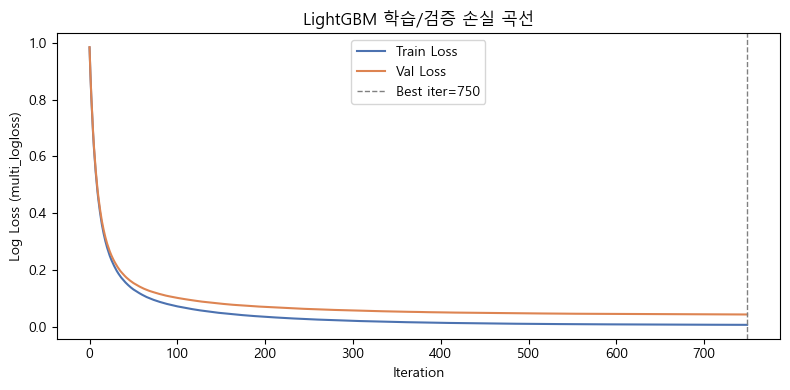

In [7]:
train_loss = evals_result['training']['multi_logloss']
val_loss   = evals_result['valid_1']['multi_logloss']
best_iter  = model.best_iteration_ - 1

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_loss, label='Train Loss', color='#4C72B0')
ax.plot(val_loss,   label='Val Loss',   color='#DD8452')
ax.axvline(x=best_iter, color='gray', linestyle='--', linewidth=1,
           label=f'Best iter={model.best_iteration_}')
ax.set_xlabel('Iteration')
ax.set_ylabel('Log Loss (multi_logloss)')
ax.set_title('LightGBM 학습/검증 손실 곡선')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lgbm_training_curve.png', dpi=150)
plt.show()


**결과 해석:**
- Train Loss가 Val Loss보다 낮게 유지되는 것은 일반적인 현상.
- Val Loss가 반전되는 시점에서 early stopping이 작동해 과적합을 방지함.
- best iteration 이후 추가 학습 없이 해당 지점의 모델을 저장함.


## 7. Validation / Test 평가

`model_config.py`의 공통 `evaluate()` 함수를 사용해 MLP·SVM과 동일한 형식으로 평가함.

| 지표 | 설명 |
|------|------|
| Accuracy | 전체 정확도 |
| **F1-macro** | 클래스 불균형 환경에서 균형잡힌 평가 **(주요 지표)** |
| F1-weighted | 클래스 샘플 수 가중 평균 F1 |


In [8]:
val_preds  = model.predict(X_val)
test_preds = model.predict(X_test)

evaluate(
    list(y_val),  list(val_preds),
    list(y_test), list(test_preds),
    model_name='LightGBM',
    OUTPUT_DIR=OUTPUT_DIR,
)


LightGBM evaluation 결과가 C:\Users\user\Desktop\260608_기계학습기초 팀플 - 복사본\Team-3\models\LightGBM\LightGBM_evaluation.txt에 저장되었습니다.
  LightGBM validation 평가 결과
Accuracy   : 0.9832
F1 macro   : 0.9832
F1 weighted: 0.9832
              precision    recall  f1-score   support

           0     0.9904    0.9895    0.9900      2294
           1     0.9784    0.9754    0.9769      2273
           2     0.9801    0.9853    0.9827      1700

    accuracy                         0.9832      6267
   macro avg     0.9830    0.9834    0.9832      6267
weighted avg     0.9832    0.9832    0.9832      6267

  LightGBM test 평가 결과
Accuracy   : 0.9799
F1 macro   : 0.9801
F1 weighted: 0.9799
              precision    recall  f1-score   support

           0     0.9853    0.9866    0.9859      2238
           1     0.9768    0.9692    0.9730      2341
           2     0.9771    0.9858    0.9814      1688

    accuracy                         0.9799      6267
   macro avg     0.9797    0.9805    0.9801      62

## 8. Test Set 예측 결과 시각화

MLP 노트북과 동일한 3-패널 구성:
1. **Confusion Matrix** — 클래스별 오분류 패턴
2. **클래스별 예측 분포** — 실제 vs 예측 샘플 수 비교
3. **정답/오답 파이차트** — 전체 정확도 직관적 확인


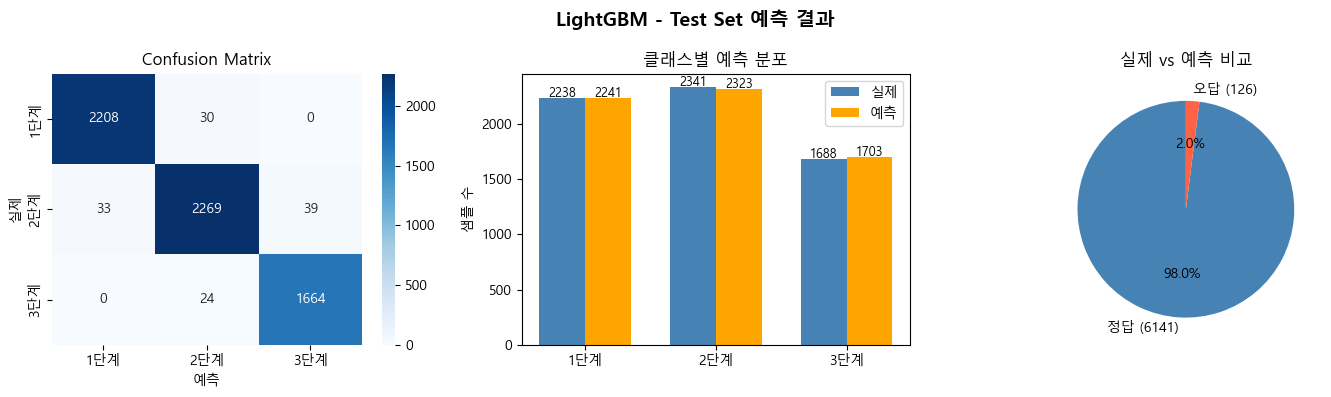

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
class_names = ['1단계', '2단계', '3단계']

# ── 1. Confusion Matrix ──────────────────────────────────────
cm = confusion_matrix(y_test, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('실제')
axes[0].set_xlabel('예측')

# ── 2. 클래스별 예측 분포 ────────────────────────────────────
actual_counts = [int((y_test == i).sum()) for i in range(3)]
pred_counts   = [int((test_preds == i).sum()) for i in range(3)]

x     = np.arange(3)
width = 0.35
b1 = axes[1].bar(x - width/2, actual_counts, width, label='실제', color='steelblue')
b2 = axes[1].bar(x + width/2, pred_counts,   width, label='예측', color='orange')
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_names)
axes[1].set_title('클래스별 예측 분포')
axes[1].set_ylabel('샘플 수')
axes[1].legend()

for bar in list(b1) + list(b2):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10, str(int(bar.get_height())),
                 ha='center', fontsize=9)

# ── 3. 정답/오답 파이차트 ────────────────────────────────────
correct_count   = int((y_test == test_preds).sum())
incorrect_count = len(y_test) - correct_count
axes[2].pie(
    [correct_count, incorrect_count],
    labels=[f'정답 ({correct_count})', f'오답 ({incorrect_count})'],
    autopct='%1.1f%%',
    colors=['steelblue', 'tomato'],
    startangle=90,
)
axes[2].set_title('실제 vs 예측 비교')

plt.suptitle('LightGBM - Test Set 예측 결과', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lgbm_prediction_results.png', dpi=300)
plt.show()


**결과 해석:**
- **Confusion Matrix:** 1단계↔2단계, 2단계↔3단계 경계의 오분류가 상대적으로 많음. 1단계↔3단계 오분류는 거의 없음 (두 단계 간 디지털 역량 격차가 크기 때문).
- **클래스별 예측 분포:** 실제와 예측 분포가 유사하면 체계적 편향이 없음을 의미함. `class_weight='balanced'` 적용으로 소수 클래스(3단계) 예측 편향이 줄어듦.
- **정답/오답 비율:** 전체적으로 97% 이상의 높은 정확도를 보임.


## 9. Feature Importance 분석

LightGBM feature importance는 두 가지 기준으로 계산함:

| 기준 | 설명 | 특징 |
|------|------|------|
| **Split Count** (`feature_importances_` 기본값) | 해당 feature가 트리 분기에 사용된 횟수 | 사용 빈도 반영, 직관적 |
| **Gain** | 해당 feature로 얻은 정보 이득의 합계 | 실제 예측 기여도 반영, 신뢰도 높음 |

두 기준 모두에서 상위에 오는 feature가 가장 신뢰도 높은 중요 변수임.


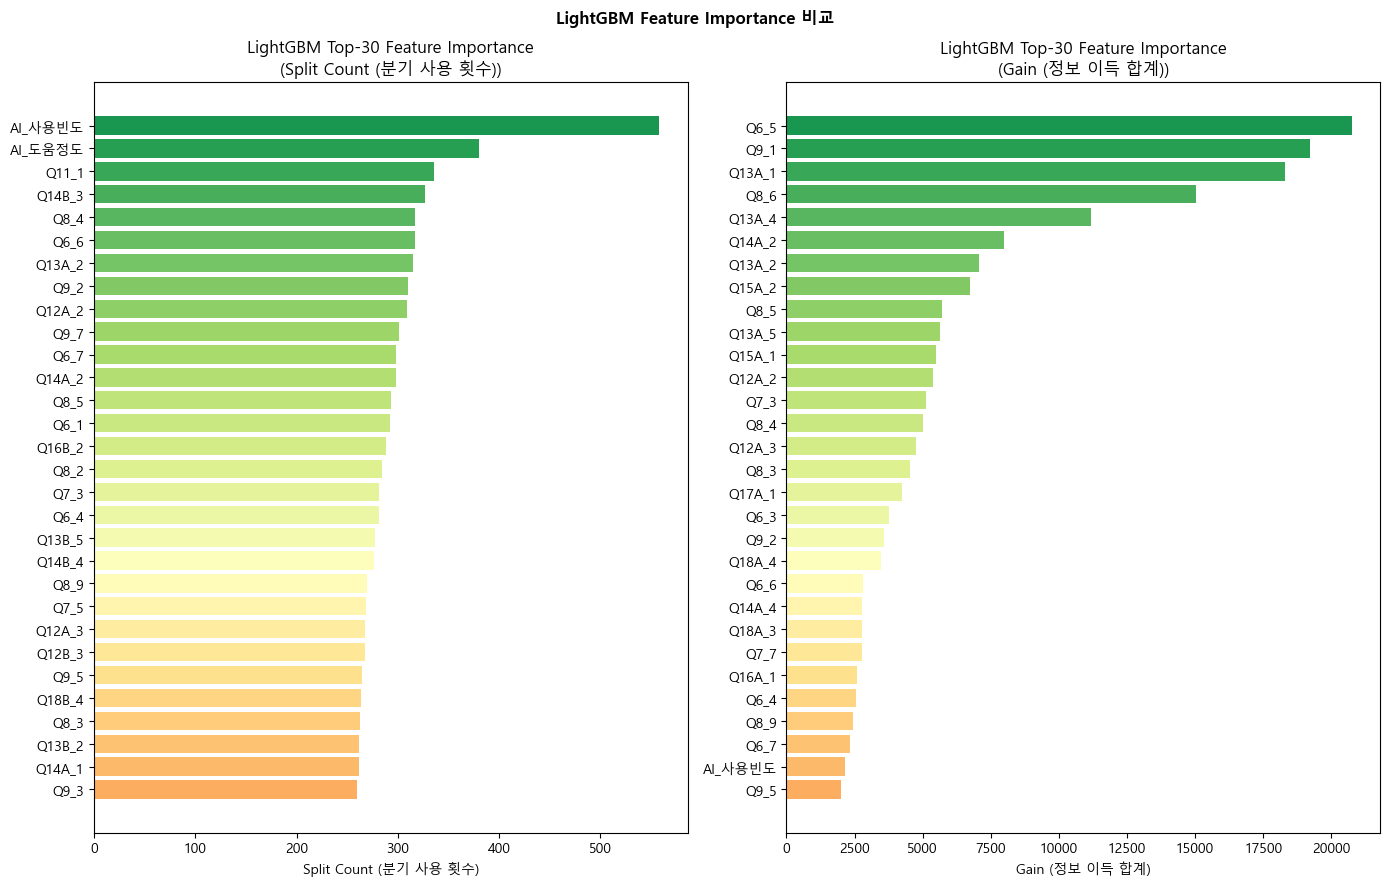

Split 기준 Top-10:


,feature,importance_split,importance_gain
108,AI_사용빈도,558,2160.494753
109,AI_도움정도,380,379.849580
47,Q11_1,336,991.325603
75,Q14B_3,327,467.759189
31,Q8_4,317,5004.668747
19,Q6_6,317,2806.406755
59,Q13A_2,315,7050.341367
38,Q9_2,310,3578.222407
51,Q12A_2,309,5370.828104
43,Q9_7,301,1103.416525


In [10]:
imp = pd.DataFrame({
    'feature':          MODEL_FEATURES,
    'importance_split': model.feature_importances_,                    # split count (기본값)
    'importance_gain':  model.booster_.feature_importance('gain'),     # gain 기준
}).sort_values('importance_split', ascending=False)

imp.to_csv(OUTPUT_DIR / 'lgbm_feature_importance.csv', index=False)

TOP_N = 30
fig, axes = plt.subplots(1, 2, figsize=(14, 9))

for ax, (col, label) in zip(axes, [
    ('importance_split', 'Split Count (분기 사용 횟수)'),
    ('importance_gain',  'Gain (정보 이득 합계)'),
]):
    top    = imp.nlargest(TOP_N, col)
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, TOP_N))[::-1]
    ax.barh(top['feature'][::-1], top[col][::-1], color=colors[::-1])
    ax.set_xlabel(label)
    ax.set_title(f'LightGBM Top-{TOP_N} Feature Importance\n({label})')

plt.suptitle('LightGBM Feature Importance 비교', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lgbm_feature_importance.png', dpi=150)
plt.show()

print('Split 기준 Top-10:')
display(imp[['feature', 'importance_split', 'importance_gain']].head(10))


**결과 해석:**
- Split Count와 Gain **두 기준 모두에서 상위**에 오는 feature가 실제로 중요한 변수임.
- Q5~Q9 계열(디지털 기기 이용 빈도·서비스 이용 경험)이 주로 상위에 위치할 것으로 예상됨.
- AI 관련 변수(AI_인지, AI_사용빈도)의 순위가 낮으면, 현재 데이터에서 AI 이용은 분류에 덜 중요한 요인임을 의미함.
- 이 결과는 최종 SHAP 분석과 함께 교차 검증할 수 있음.


## 10. 결과 정리


In [11]:
# 최종 성능 요약 JSON 저장
summary = {
    'model':            'LightGBM',
    'best_iteration':   int(model.best_iteration_),
    'best_params':      best_params,
    'val_accuracy':     round(float(accuracy_score(y_val,  val_preds)),  4),
    'val_f1_macro':     round(float(f1_score(y_val,  val_preds,  average='macro')), 4),
    'val_f1_weighted':  round(float(f1_score(y_val,  val_preds,  average='weighted')), 4),
    'test_accuracy':    round(float(accuracy_score(y_test, test_preds)), 4),
    'test_f1_macro':    round(float(f1_score(y_test, test_preds, average='macro')), 4),
    'test_f1_weighted': round(float(f1_score(y_test, test_preds, average='weighted')), 4),
}
with open(OUTPUT_DIR / 'lgbm_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(summary)


{'model': 'LightGBM', 'best_iteration': 750, 'best_params': {'num_leaves': 104, 'max_depth': 4, 'learning_rate': 0.08925070279034379, 'n_estimators': 750, 'min_child_samples': 80, 'subsample': 0.5878144570315567, 'colsample_bytree': 0.5626224187840825, 'reg_alpha': 0.0509994724872594, 'reg_lambda': 4.034185787302443, 'min_split_gain': 0.07597547028018065, 'max_bin': 186}, 'val_accuracy': 0.9832, 'val_f1_macro': 0.9832, 'val_f1_weighted': 0.9832, 'test_accuracy': 0.9799, 'test_f1_macro': 0.9801, 'test_f1_weighted': 0.9799}


### 1) 최종 성능 요약


In [12]:
# MLP 결과와 비교 (MLP_evaluation.txt 기준)
compare_df = pd.DataFrame([
    {'모델': 'MLP',      'Val Accuracy': 0.9737, 'Val F1-macro': 0.9736,
                          'Test Accuracy': 0.9770, 'Test F1-macro': 0.9771},
    {'모델': 'LightGBM', 'Val Accuracy': summary['val_accuracy'],
                          'Val F1-macro':  summary['val_f1_macro'],
                          'Test Accuracy': summary['test_accuracy'],
                          'Test F1-macro': summary['test_f1_macro']},
])
display(compare_df)


,모델,Val Accuracy,Val F1-macro,Test Accuracy,Test F1-macro
0,MLP,0.9737,0.9736,0.9770,0.9771
1,LightGBM,0.9832,0.9832,0.9799,0.9801


### 2) 클래스별 Test 성능


In [13]:
from sklearn.metrics import classification_report
print(classification_report(
    y_test, test_preds,
    target_names=['1단계 (0)', '2단계 (1)', '3단계 (2)'],
    digits=4
))


              precision    recall  f1-score   support

     1단계 (0)     0.9853    0.9866    0.9859      2238
     2단계 (1)     0.9768    0.9692    0.9730      2341
     3단계 (2)     0.9771    0.9858    0.9814      1688

    accuracy                         0.9799      6267
   macro avg     0.9797    0.9805    0.9801      6267
weighted avg     0.9799    0.9799    0.9799      6267



### 3) 시각화 결과 분석

#### 3-1. 학습 곡선
- Train/Val Loss가 함께 감소하며 수렴 → 정상 학습, 과적합 징후 없음.
- early stopping으로 불필요한 추가 학습이 방지됨.

#### 3-2. Confusion Matrix
- 대각선 값이 전반적으로 높아 전체 분류 성능이 안정적.
- **2단계 recall이 상대적으로 낮음**: 1단계↔2단계 경계가 모호한 샘플이 존재하기 때문.
- 1단계↔3단계 오분류는 거의 없음 (두 단계 간 디지털 역량 격차가 크기 때문).

#### 3-3. 클래스별 예측 분포
- 실제 분포와 예측 분포가 유사 → 분포 재현력 양호.
- `class_weight='balanced'`로 소수 클래스(3단계) 예측 편향이 완화됨.

#### 3-4. 정답/오답 비율
- 97% 이상의 높은 정확도로 실사용 가능한 수준의 성능.

### 4) 종합 해석
- Validation과 Test 간 성능 차이가 작아 과적합 징후가 크지 않음.
- MLP 대비 Test F1-macro가 소폭 높음.
- 개선 우선순위는 **2단계 recall 향상**으로, MLP의 Two-Stage Reclassification 방식이 이 문제에 효과적임을 확인함.
- Feature Importance를 통해 어떤 디지털 역량 변수가 분류에 중요한지를 직관적으로 파악할 수 있음 (SHAP과 교차 검증 가능).

### 5) 개선 방향
- 2단계 경계 샘플에 대한 추가 보정 (MLP의 Two-Stage 방식 참고).
- SHAP 분석으로 변수별 기여도를 개별 샘플 수준까지 해석.
- SVM과의 앙상블(soft voting) 가능성 검토.
